# Project Overview

This project extracts structured knowledge graphs from Dark Souls Wiki content, leveraging a combination of web scraping, LLM-based parsing, and graph databases. The workflow consists of scraping and merging raw item and NPC data, generating semantic node-edge graphs using a language model, and visualising or importing these graphs into Neo4j for exploration and querying.


In [ ]:
%pip install -r requirements.txt

In [1]:
# Built-in modules
import os
import re
import json
import time
from pathlib import Path
from typing import List, Dict, Optional, Any

# Third-party libraries
import requests
from bs4 import BeautifulSoup
from bs4.element import Tag
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
from neo4j import GraphDatabase
from openai import OpenAI

## Why Use Only the Wikidot Dark Souls Wiki?

For this project, only the **Wikidot Dark Souls Wiki** was selected as the data source. This choice was made for several reasons:

- ✅ **Consistency of layout:** Compared to other wikis, the Wikidot site presents information in a highly consistent and predictable HTML structure, which makes scraping much more reliable and reduces the need for site-specific exceptions or heuristics.

- ✅ **Better formatting:** The tables, item pages, and NPC pages are uniformly styled and easier to parse programmatically compared to alternatives, which often mix inconsistent HTML patterns and embedded ads.

- ✅ **Reusability for future games:** The Wikidot platform also hosts similar wikis for *Dark Souls II*, *Dark Souls III*, and other FromSoftware titles, with nearly identical formatting. This means the existing scraper and pipeline can be easily adapted to those games with minimal changes, ensuring extensibility and scalability.

This focused approach reduced complexity and improved the robustness of the scraping pipeline while laying the groundwork for possible future expansions.


In [2]:
from scraper import main, dialogue_scrape, desc_scrape
from merger import merge_item_jsons, append_npcs_to_items
from graph import *


### Run Full Scraping and Saving Pipeline

This line runs the `main()` function from the `scraper.py` module.  
It executes the full scraping pipeline: visiting Dark Souls Wiki pages, extracting structured data for items, NPCs, weapons, armor, spells, and more, and saving each category as a JSON file in the `JSON/` directory.  
It ensures the data is downloaded and stored locally for further processing in the next steps.


In [3]:
main()

Scraping gifts...
8 entities scraped. Saved results to JSON/gifts.json
Scraping weapons...
119 entities scraped. Saved results to JSON/weapons.json
Scraping shields...
45 entities scraped. Saved results to JSON/shields.json
Scraping spell_tools...
20 entities scraped. Saved results to JSON/spell_tools.json
Scraping items...
166 entities scraped. Saved results to JSON/items.json
Scraping armor...
68 entities scraped. Saved results to JSON/armor.json
Scraping chest_armor...
58 entities scraped. Saved results to JSON/chest_armor.json
Scraping hands_armor...
54 entities scraped. Saved results to JSON/hands_armor.json
Scraping legs_armor...
58 entities scraped. Saved results to JSON/legs_armor.json
Scraping pyromancies...
20 entities scraped. Saved results to JSON/pyromancies.json
Scraping sorceries...
28 entities scraped. Saved results to JSON/sorceries.json
Scraping miracles...
23 entities scraped. Saved results to JSON/miracles.json
Scraping materials...
14 entities scraped. Saved result

### Enrich Data with Descriptions and Dialogues

These two functions add additional context to the scraped data:

- `desc_scrape()`: Visits each item's individual wiki page and extracts its in-game description. The descriptions are added to the item records and saved into `items_merged_with_desc.json`.

- `dialogue_scrape()`: Visits each NPC's wiki page and extracts their dialogue lines. The dialogues are added to the NPC records and saved into `npcs_with_dialogue.json`.

These enrichments provide the text needed for semantic parsing in the next step.


### Merge Data

These two functions combine the various JSON files into consolidated datasets:

- `merge_item_jsons()`: Merges all individual item-related JSON files (armor, weapons, spells, etc.) into a single file, `items_merged.json`, for easier processing.

- `append_npcs_to_items()`: Takes the enriched items (with descriptions) and appends the enriched NPCs (with dialogues) into a unified dataset, saved as `items_npcs_merged.json`.

This produces one complete file containing all entities and their textual context, ready for semantic graph generation.


In [6]:
merge_item_jsons()
desc_scrape()
dialogue_scrape()
append_npcs_to_items()

✅ Merged 691 entities into JSON/items_merged.json
Processed 25/691 items...
Processed 50/691 items...
Processed 75/691 items...
Processed 100/691 items...
Processed 125/691 items...
Processed 150/691 items...
Processed 175/691 items...
Processed 200/691 items...
Processed 225/691 items...
Processed 250/691 items...
Processed 275/691 items...
Processed 300/691 items...
Processed 325/691 items...
Processed 350/691 items...
Processed 375/691 items...
Processed 400/691 items...
Processed 425/691 items...
Processed 450/691 items...
Processed 475/691 items...
Processed 500/691 items...
Processed 525/691 items...
Processed 550/691 items...
Processed 575/691 items...
Processed 600/691 items...
Processed 625/691 items...
Processed 650/691 items...
Processed 675/691 items...
Processed 691/691 items...
Saved 691 items with descriptions to JSON/items_merged_with_desc.json
Processed 1/50 NPCs...
Processed 2/50 NPCs...
Processed 3/50 NPCs...
Processed 4/50 NPCs...
Processed 5/50 NPCs...
Processed 6/

741

### Generate Semantic Graphs with GPT-4o-mini

This line runs the `request.py` script, which sends each entity’s description or dialogue from `items_npcs_merged.json` to the GPT-4o-mini API.  
The model analyzes the text and extracts a semantic graph for each entity, identifying:
- **Nodes:** key concepts or entities
- **Edges:** labeled relationships between nodes

The results are saved into `nodes_edges.json`, which represents the full knowledge graph in a structured JSON format.  
This step leverages the power of LLMs, which significantly outperform regex and pre-trained models for extracting nuanced, domain-specific relationships.

**Note:** This step takes approximately 40 minutes to complete. Since the output file `nodes_edges.json` is already included in the project files, it is recommended to skip running this code unless you wish to regenerate the results.


In [ ]:
#%run request.py

### Explore the Graph with Queries

The `graph.py` module provides an interactive way to explore the generated semantic graph and answer specific questions about the relationships between entities.  
It loads the `nodes_edges.json` file into a NetworkX directed graph, allowing you to query and visualize subgraphs based on node names and optional relationship filters. It also returns the answer data and prints a one-sentence interpretation.






1. Who are the Sealers of New Londo?


✅ Found 1 edges for query 'Sealers of New Londo' with relationship filter 'member':
Yulva is a member of Sealers of New Londo


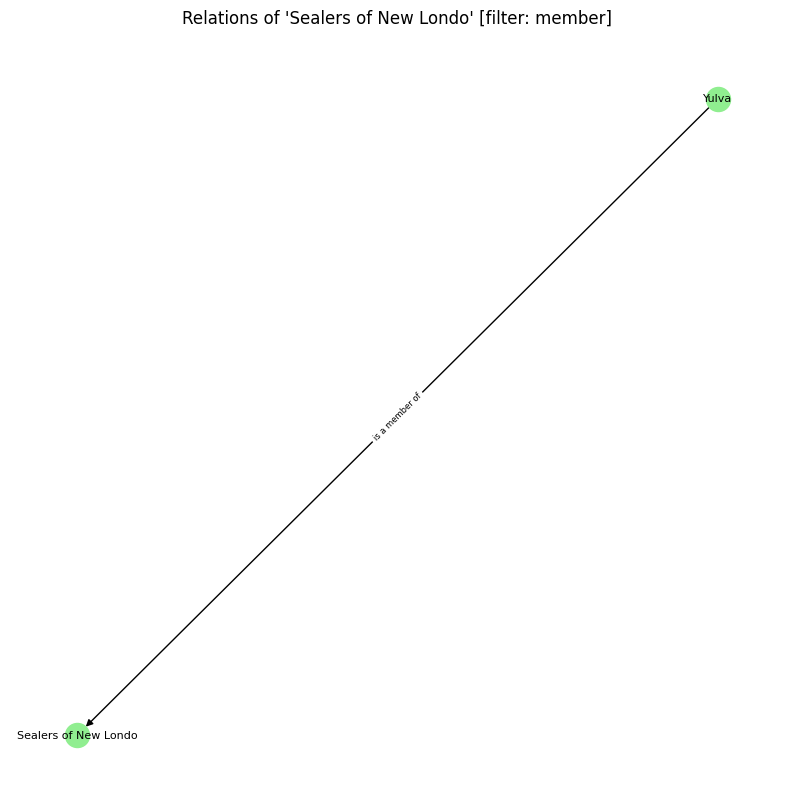

In [8]:
load_graph_and_plot_query("Sealers of New Londo","member")

2. Who are located in Catacombs?


✅ Found 3 edges for query 'Catacombs' with relationship filter 'located in':
Vamos located in Catacombs
skeletons located in Catacombs
Trusty Patches located in Catacombs


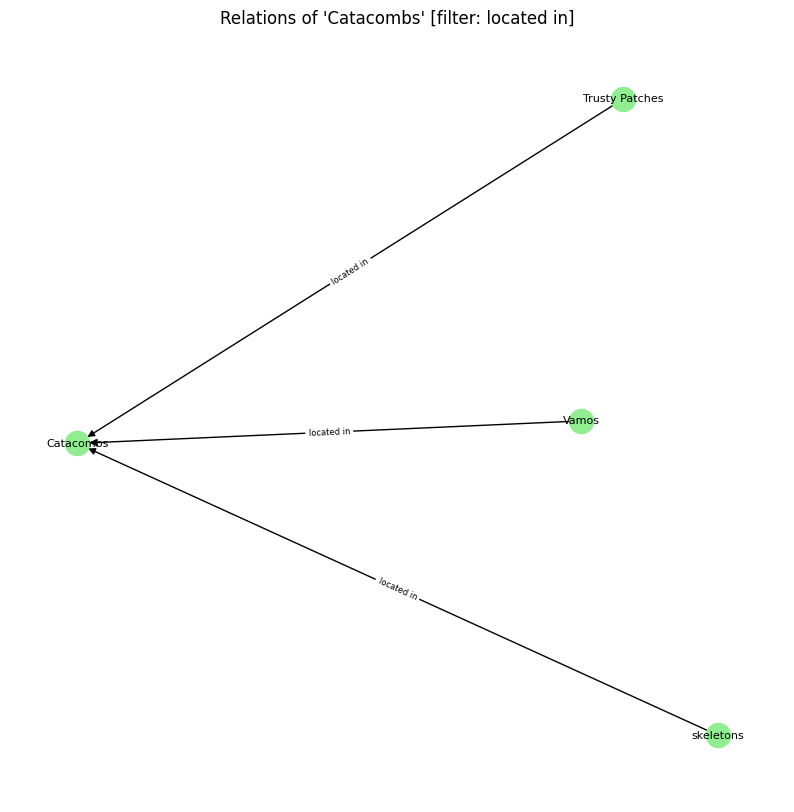

In [7]:
load_graph_and_plot_query("Catacombs","located in")


3. What does giant Undead wield?


✅ Found 1 edges for query 'giant Undead' with relationship filter 'wield':
giant Undead wield Large wooden club


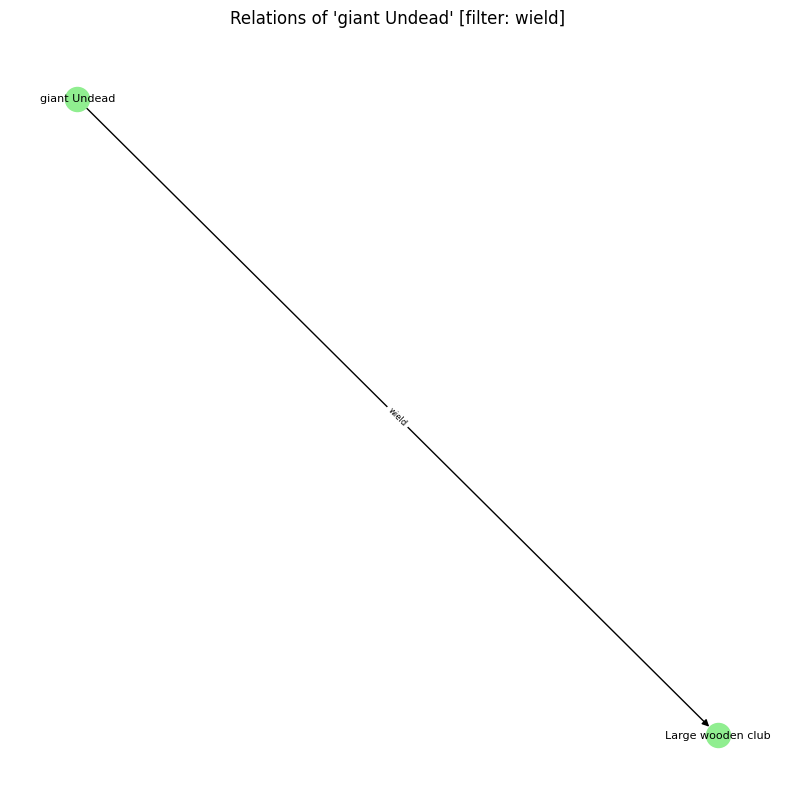

In [9]:
load_graph_and_plot_query("giant Undead","wield")


4. What grants poison resistance?


✅ Found 5 edges for query 'Poison' with relationship filter 'resist':
gold-hemmed black hood offers resistance versus poison
gold-hemmed black cloak offers strong resistance versus poison
gloves offer resistance versus poison
gold-hemmed black skirt offers resistance versus poison
Shield of the savage mountain bandits resistance to poison


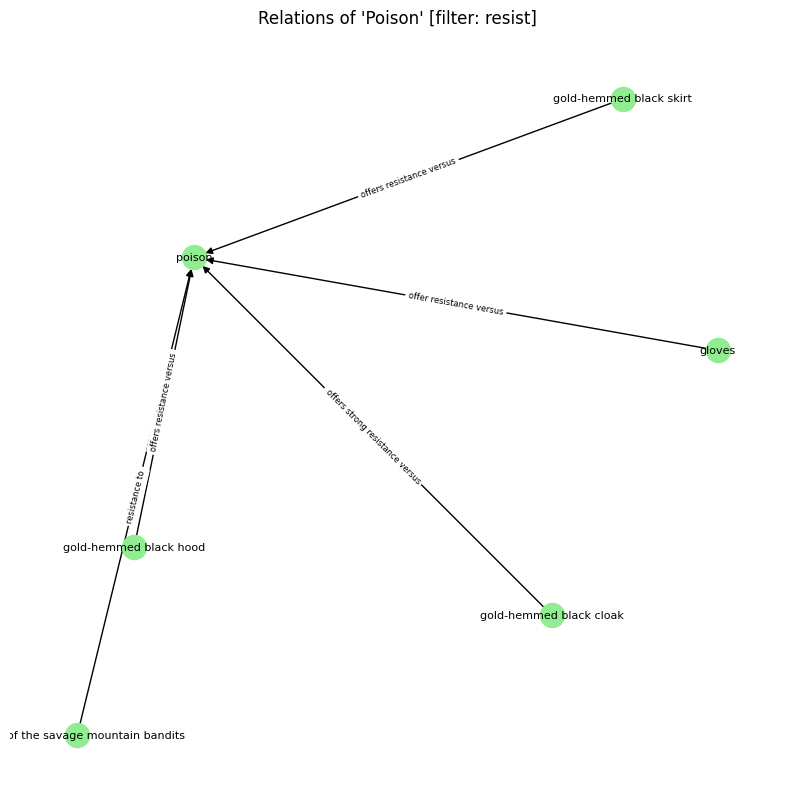

In [10]:
load_graph_and_plot_query("Poison","resist")

5. What items are located in Undead Parish?


✅ Found 2 edges for query 'Undead Parish' with relationship filter 'found':
key found in Undead Parish
medium metal shield found in Undead Parish


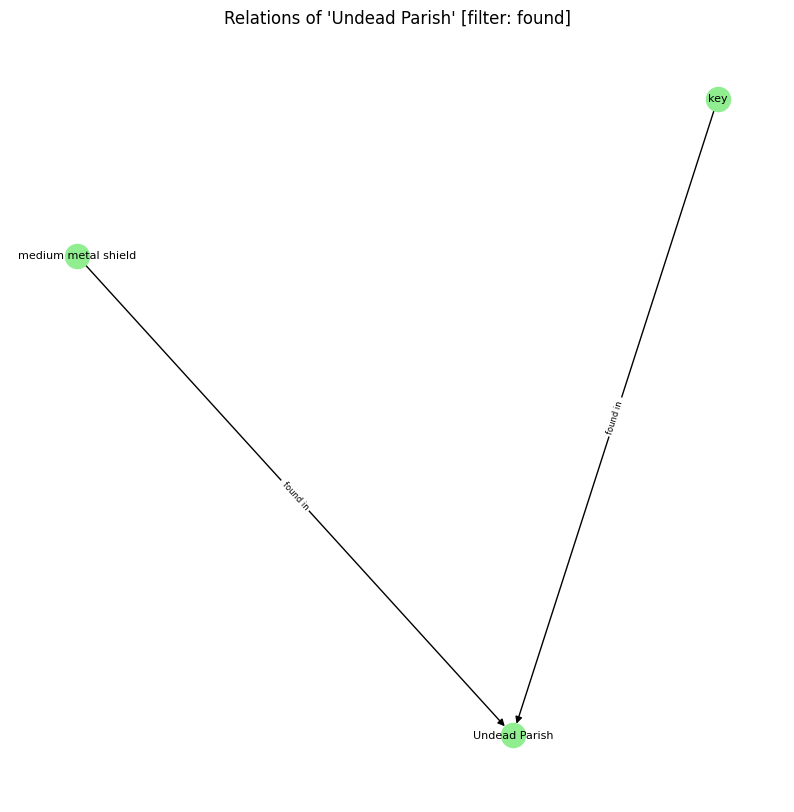

In [11]:
load_graph_and_plot_query("Undead Parish","found")

## Neo4j Graph

The Neo4j version of the code requires the Neo4j Desktop app to work correctly.
After running the code below, open http://localhost:7474/ in your browser and log in with the following credentials:
user = "neo4j"
password = "mypassword" 

In [ ]:
%run graph_to_neo4j.py

Here are the Cypher queries of the previous searches done in networkx:

## Insights & Closing Thoughts

Working on this project has been an incredibly rewarding experience that pushed me to apply and grow my technical, problem solving, and creative skills. Designing and implementing a full pipeline, from web scraping and data cleaning to semantic graph generation, visualization, and Neo4j integration, taught me how to break down a vague, open ended challenge into manageable, well defined steps. One of the most exciting aspects of this work was experimenting with different approaches to natural language understanding. Initially, I tried using regular expressions and pre trained models for relationship extraction but quickly realized their limitations with nuanced, domain specific text. Leveraging GPT 4o mini was a breakthrough as it delivered high quality, context aware semantic graphs with minimal overhead and really showed me how transformative large language models can be when used effectively. I also appreciated how extensible the solution became by sticking to clean data formats (JSON) and modular code which makes it easy to reuse or adapt for other games or datasets in the future. I’m proud of how I integrated multiple technologies including Python automation, web scraping, AI APIs, NetworkX, and Neo4j into a coherent end to end workflow. Beyond coding, I learned how to document my process, communicate results clearly, and maintain a professional standard of work. This project has solidified my passion for working at the intersection of AI, data, and software engineering. I’m eager to develop and bring this mindset and these skills into my career, tackling similar problems with creativity, curiosity, and an enthusiasm for learning and building impactful technology solutions.